# Modelado de Fuentes — NYC 311 Service Requests
## Modelado analítico y preparación de fuentes para Tableau

**Input**: `outputs/week-03-311/311_clean.csv` — dataset limpio del notebook anterior  
**Objetivo**: construir un modelo analítico tipo estrella (fact + dimensiones), validar integridad relacional y exportar fuentes listas para conectar en Tableau sin reprocesamiento.

**Referencia metodológica**: sigue la estructura del notebook semana-04 del curso, adaptada al dataset NYC 311.


---
## 0. Setup


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from _shared import ensure_output_dir

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

WEEK       = 'week-04-311'
CLEAN_PATH = ROOT / 'outputs' / 'week-03-311' / '311_clean.csv'
OUTPUT_DIR = ROOT / 'outputs' / WEEK
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input:  {CLEAN_PATH}  →  existe: {CLEAN_PATH.exists()}')
print(f'Output: {OUTPUT_DIR}')

Input:  c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\outputs\week-03-311\311_clean.csv  →  existe: False
Output: c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\outputs\week-04-311


In [2]:
from pathlib import Path

# Busca todos los archivos que se llamen 311_clean.csv en el proyecto
ROOT = Path.cwd().parent
resultados = list(ROOT.rglob('311_clean.csv'))

if resultados:
    for r in resultados:
        print(r)
else:
    print('No se encontró 311_clean.csv — verifica que la limpieza haya terminado de exportar')

c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\notebooks\outputs\week-03-311\311_clean.csv


In [3]:
CLEAN_PATH = Path.cwd() / 'outputs' / 'week-03-311' / '311_clean.csv'
OUTPUT_DIR = Path.cwd() / 'outputs' / WEEK
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1. Carga del dataset limpio

Leemos el CSV exportado por el notebook de limpieza. Este es el único input de este notebook — el principio de separación de etapas garantiza que el modelado no dependa de la carga cruda.


In [4]:
df = pd.read_csv(
    CLEAN_PATH,
    parse_dates=['Created Date', 'Closed Date', 'date'],
    low_memory=False,
)

print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head(3)

Shape: (94500, 23)
Columnas: ['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Problem', 'Problem Detail', 'Incident Zip', 'Status', 'Community Board', 'Council District', 'Police Precinct', 'Borough', 'Open Data Channel Type', 'Latitude', 'Longitude', 'year', 'month', 'month_name', 'day_of_week', 'hour_of_day', 'date', 'resolution_hours', 'resolution_days']


,Unique Key,Created Date,Closed Date,Agency,Problem,Problem Detail,Incident Zip,Status,Community Board,Council District,...,Latitude,Longitude,year,month,month_name,day_of_week,hour_of_day,date,resolution_hours,resolution_days
0,68669433,2026-04-14 05:10:42,2026-04-14 10:15:35,NYPD,Illegal Parking,Blocked Hydrant,11209.0,CLOSED,10 BROOKLYN,47.0,...,40.616921,-74.032987,2026,4,April,Tuesday,5,2026-04-14,5.081389,0.211725
1,68689064,2026-04-16 08:10:51,2026-04-16 13:12:23,NYC311-PRD,Street Condition,Defective Hardware,11377.0,CLOSED,01 QUEENS,22.0,...,40.762760,-73.904837,2026,4,April,Thursday,8,2026-04-16,5.025556,0.209398
2,68687035,2026-04-17 00:51:18,NaT,NYPD,Illegal Parking,Blocked Hydrant,11236.0,IN PROGRESS,18 BROOKLYN,46.0,...,40.643372,-73.888039,2026,4,April,Friday,0,2026-04-17,NaN,NaN


---
## 2. Diseño del modelo analítico

### Comparación de enfoques: dos alternativas evaluadas

Antes de construir el modelo, se evaluaron dos enfoques analíticos con criterios explícitos.
La elección no se basa en preferencia técnica sino en las restricciones del problema:
dataset de ~20M filas, objetivo de reproducibilidad para portafolio, y entrega final en Tableau.

| Criterio | **Enfoque base** — tabla plana + cálculos en Tableau | **Enfoque elegido** — modelo estrella + agregaciones en Python |
|---|---|---|
| Reproducibilidad | Baja: los campos calculados de Tableau no se versionan en Git | Alta: cada métrica es una celda auditable en este notebook |
| Transparencia analítica | Media: la lógica de negocio queda dentro del workbook | Alta: las decisiones (mediana vs media, agrupación de problemas) están documentadas aquí |
| Rendimiento con 20M filas | Variable: Tableau carga y agrega en tiempo real | Controlado: Tableau solo lee CSVs pre-agregados, sin recalcular |
| Mantenimiento | Alto: cambiar una métrica requiere abrir Tableau y modificar el workbook | Bajo: cambiar Python y re-exportar actualiza todas las vistas |
| Consistencia entre vistas | Riesgo de divergencia si hay múltiples campos calculados similares | Garantizada: todas las vistas consumen la misma fuente exportada |

**Conclusión**: el enfoque base es viable para datasets pequeños o proyectos de uso único.
Para un dataset de esta escala y con requisito de portafolio auditable, el modelo estrella
con agregaciones pre-calculadas en Python es la opción más defensible técnica y metodológicamente.

### Estructura del modelo estrella elegido

```
fact_311 (una fila por solicitud 311)
  │
  ├── dim_fecha     (date)     → Year / Quarter / Month / Day of Week / is_weekend
  ├── dim_geo       (Borough)  → 5 boroughs válidos de NYC
  ├── dim_agencia   (Agency)   → agencias municipales responsables
  └── dim_problema  (Problem)  → 272 tipos + agrupación en 11 familias temáticas
```

La separación fact/dimensiones permite a Tableau construir relaciones correctas (Tableau 2020.2+)
sin inflar métricas al hacer joins — problema conocido cuando se usa una sola tabla plana
con múltiples niveles de agregación simultáneos.


In [5]:
# ── Evidencia cuantitativa: tamaño base de la tabla plana ─────────────────────
# Se mide ANTES de construir el modelo para tener la referencia del enfoque base.

size_flat_mb = df.memory_usage(deep=True).sum() / 1e6

print('=' * 55)
print('  Referencia de tamaño: tabla plana (enfoque base)')
print('=' * 55)
print(f'  Memoria en RAM:        {size_flat_mb:>8.1f} MB')
print(f'  Filas totales:         {len(df):>8,}')
print(f'  Columnas totales:      {df.shape[1]:>8}')
print()
print('  El tamaño del modelo estrella se medirá en la')
print('  Sección 6, una vez construidas todas las tablas.')
print('=' * 55)

  Referencia de tamaño: tabla plana (enfoque base)
  Memoria en RAM:            72.2 MB
  Filas totales:           94,500
  Columnas totales:            23

  El tamaño del modelo estrella se medirá en la
  Sección 6, una vez construidas todas las tablas.


---
## 3. Construcción de dimensiones


### 3.1 dim_fecha

Dimensión de tiempo: una fila por día único del dataset. Permite a Tableau construir jerarquías Year → Month → Day sin cálculos adicionales.


In [6]:
dim_fecha = pd.DataFrame({
    'date': pd.to_datetime(sorted(df['date'].dropna().unique()))
})
dim_fecha['year']        = dim_fecha['date'].dt.year
dim_fecha['quarter']     = dim_fecha['date'].dt.quarter
dim_fecha['month']       = dim_fecha['date'].dt.month
dim_fecha['month_name']  = dim_fecha['date'].dt.month_name()
dim_fecha['day_of_week'] = dim_fecha['date'].dt.day_name()
dim_fecha['is_weekend']  = dim_fecha['date'].dt.dayofweek >= 5

print(f'dim_fecha: {dim_fecha.shape}')
dim_fecha.head(5)

dim_fecha: (962, 7)


,date,year,quarter,month,month_name,day_of_week,is_weekend
0,2023-08-30,2023,3,8,August,Wednesday,False
1,2023-08-31,2023,3,8,August,Thursday,False
2,2023-09-01,2023,3,9,September,Friday,False
3,2023-09-02,2023,3,9,September,Saturday,True
4,2023-09-03,2023,3,9,September,Sunday,True


### 3.2 dim_geografía

Dimensión geográfica: Borough como nivel principal. Una fila por borough único. Permite filtros y mapas en Tableau sin repetir la etiqueta en cada fila de hechos.


In [7]:
dim_geo = (
    df[['Borough']]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_geo['borough_id'] = range(1, len(dim_geo) + 1)
dim_geo = dim_geo[['borough_id', 'Borough']]

print(f'dim_geo: {dim_geo.shape}')
print(dim_geo)

dim_geo: (5, 2)
   borough_id        Borough
0           1       Brooklyn
1           2         Queens
2           3      Manhattan
3           4          Bronx
4           5  Staten Island


### 3.3 dim_problema

Dimensión de tipo de problema. Aquí se aplica la **agrupación analítica** que fue deliberadamente postergada en el notebook de limpieza: reducir los 272 valores únicos de `Problem` a categorías manejables para Tableau.

**Justificación de la agrupación**: 272 categorías no son visualizables en un gráfico de barras. La agrupación en familias temáticas permite responder la pregunta "¿qué tipo de problemas son más frecuentes?" sin perder granularidad — `Problem` original se conserva en la tabla de hechos.

**Alternativa descartada**: usar solo las top-N categorías por frecuencia. Se descartó porque agrupa por popularidad, no por semántica — un Ruido nocturno y un Ruido de construcción quedarían en grupos distintos aunque sean la misma familia de problema.


In [8]:
dim_problema = (
    df[['Problem', 'Problem Detail']]
    .drop_duplicates(subset=['Problem'])
    .dropna(subset=['Problem'])
    .reset_index(drop=True)
)

# Agrupación en familias temáticas — decisión analítica documentada
def clasificar_problema(p):
    p = str(p).upper()
    if 'NOISE' in p:                               return 'Ruido'
    if 'HEAT' in p or 'HOT WATER' in p:            return 'Calefacción / Agua Caliente'
    if 'ILLEGAL PARKING' in p or 'BLOCKED' in p:   return 'Tráfico / Estacionamiento'
    if 'SANITATION' in p or 'DIRTY' in p or 'LITTER' in p: return 'Saneamiento'
    if 'STREET' in p or 'SIDEWALK' in p or 'POTHOLE' in p: return 'Infraestructura vial'
    if 'WATER' in p or 'SEWER' in p:              return 'Agua / Alcantarillado'
    if 'TREE' in p or 'PARK' in p:                return 'Árboles / Parques'
    if 'HOUSING' in p or 'APARTMENT' in p:        return 'Vivienda'
    if 'GRAFFITI' in p:                            return 'Graffiti'
    if 'RODENT' in p or 'PEST' in p:              return 'Plagas / Roedores'
    return 'Otros'

dim_problema['problem_family'] = dim_problema['Problem'].apply(clasificar_problema)

print(f'dim_problema: {dim_problema.shape}')
print('\nDistribución por familia:')
print(dim_problema['problem_family'].value_counts())

dim_problema: (187, 3)

Distribución por familia:
problem_family
Otros                          138
Agua / Alcantarillado           12
Infraestructura vial             9
Árboles / Parques                9
Ruido                            8
Saneamiento                      4
Calefacción / Agua Caliente      3
Tráfico / Estacionamiento        2
Plagas / Roedores                1
Graffiti                         1
Name: count, dtype: int64


### 3.4 dim_agencia

Dimensión de agencias responsables. Una fila por agencia única.


In [9]:
dim_agencia = (
    df[['Agency']]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_agencia['agency_id'] = range(1, len(dim_agencia) + 1)
dim_agencia = dim_agencia[['agency_id', 'Agency']]

print(f'dim_agencia: {dim_agencia.shape}')
print(dim_agencia.to_string())

dim_agencia: (16, 2)
    agency_id      Agency
0           1        NYPD
1           2  NYC311-PRD
2           3         EDC
3           4         DOT
4           5         HPD
5           6         DPR
6           7        DSNY
7           8       DOHMH
8           9        DCWP
9          10         DOB
10         11         DEP
11         12         TLC
12         13         DHS
13         14         OOS
14         15         OTI
15         16         DOE


---
## 4. Construcción de la tabla de hechos

La tabla de hechos contiene una fila por solicitud 311. Las métricas cuantitativas van aquí; los atributos descriptivos quedan en las dimensiones y se relacionan por clave.


In [10]:
fact = df[[
    'Unique Key',           # PK de la solicitud
    'date',                 # FK → dim_fecha
    'Borough',              # FK → dim_geo
    'Agency',               # FK → dim_agencia
    'Problem',              # FK → dim_problema
    'Status',
    'Open Data Channel Type',
    'hour_of_day',
    'resolution_hours',
    'resolution_days',
    'Latitude',
    'Longitude',
    'Incident Zip',
    'Community Board',
    'Council District',
    'Police Precinct',
]].copy()

# Añadir family de problema directo en fact para facilitar filtros en Tableau
# Justificación: evita configurar la relación dim_problema en cada vista nueva
problem_family_map = dim_problema.set_index('Problem')['problem_family'].to_dict()
fact['problem_family'] = fact['Problem'].map(problem_family_map).fillna('Otros')

print(f'fact: {fact.shape}')
fact.head(3)

fact: (94500, 17)


,Unique Key,date,Borough,Agency,Problem,Status,Open Data Channel Type,hour_of_day,resolution_hours,resolution_days,Latitude,Longitude,Incident Zip,Community Board,Council District,Police Precinct,problem_family
0,68669433,2026-04-14,Brooklyn,NYPD,Illegal Parking,CLOSED,MOBILE,5,5.081389,0.211725,40.616921,-74.032987,11209.0,10 BROOKLYN,47.0,Precinct 68,Tráfico / Estacionamiento
1,68689064,2026-04-16,Queens,NYC311-PRD,Street Condition,CLOSED,UNKNOWN,8,5.025556,0.209398,40.762760,-73.904837,11377.0,01 QUEENS,22.0,Precinct 114,Infraestructura vial
2,68687035,2026-04-17,Brooklyn,NYPD,Illegal Parking,IN PROGRESS,ONLINE,0,NaN,NaN,40.643372,-73.888039,11236.0,18 BROOKLYN,46.0,Precinct 69,Tráfico / Estacionamiento


### Comparación cuantitativa: tabla plana vs modelo estrella

Se mide el tamaño en RAM de ambos enfoques para sustentar con evidencia la decisión metodológica.

In [11]:
# ── Comparación cuantitativa: tabla plana vs modelo estrella ──────────────────
size_flat = df.memory_usage(deep=True).sum() / 1e6

size_estrella = sum([
    fact.memory_usage(deep=True).sum(),
    dim_fecha.memory_usage(deep=True).sum(),
    dim_geo.memory_usage(deep=True).sum(),
    dim_agencia.memory_usage(deep=True).sum(),
    dim_problema.memory_usage(deep=True).sum(),
]) / 1e6

reduccion = (size_flat - size_estrella) / size_flat * 100

print("=" * 52)
print("  Comparación cuantitativa de enfoques")
print("=" * 52)
print(f"  Tabla plana (enfoque base):  {size_flat:>7.1f} MB")
print(f"  Modelo estrella (elegido):   {size_estrella:>7.1f} MB")
print(f"  Reducción de redundancia:    {reduccion:>7.1f} %")
print()
print(f"  Filas en tabla plana:        {len(df):>7,}")
print(f"  Filas en fact_311:           {len(fact):>7,}")
print(f"  Filas en dimensiones:        {sum([len(dim_fecha), len(dim_geo), len(dim_agencia), len(dim_problema)]):>7,}")
print("=" * 52)
print("  Conclusión: el modelo estrella reduce redundancia")
print("  y garantiza que Tableau no duplique métricas")
print("  al hacer joins entre tablas.")
print("=" * 52)

  Comparación cuantitativa de enfoques
  Tabla plana (enfoque base):     72.2 MB
  Modelo estrella (elegido):      57.7 MB
  Reducción de redundancia:       20.0 %

  Filas en tabla plana:         94,500
  Filas en fact_311:            94,500
  Filas en dimensiones:          1,170
  Conclusión: el modelo estrella reduce redundancia
  y garantiza que Tableau no duplique métricas
  al hacer joins entre tablas.


---
## 5. Métricas derivadas analíticas

Calculamos agregaciones que Tableau usará directamente. Hacerlas en Python —y no como campos calculados en Tableau— garantiza reproducibilidad y consistencia entre vistas.

### Justificación de métricas elegidas

Las métricas responden a las preguntas analíticas centrales del proyecto:

| Métrica | Pregunta que responde | Por qué esta métrica y no otra |
|---|---|---|
| Volumen por Borough y año | ¿Dónde y cuándo se concentran las solicitudes? | Conteo directo — no requiere supuestos adicionales |
| Tiempo mediano de resolución | ¿Qué tan eficiente es cada agencia? | **Mediana**, no media: la distribución es fuertemente sesgada a la derecha (outliers de miles de horas inflan la media) |
| Distribución por hora del día | ¿Cuándo reportan los ciudadanos? | Revela patrones operativos: picos nocturnos vs diurnos por tipo de problema |
| Top problemas por familia | ¿Qué tipos de problemas dominan? | La agrupación en familias reduce 272 → 11 categorías sin perder señal analítica |


In [12]:
# ── Métrica 1: Volumen por Borough y año ──────────────────────────────────────
agg_borough_year = (
    fact.merge(
        pd.read_csv(CLEAN_PATH, usecols=['Unique Key', 'year'], low_memory=False),
        on='Unique Key',
        how='left'
    )
    .groupby(['Borough', 'year'])
    .agg(n_solicitudes=('Unique Key', 'count'))
    .reset_index()
)
print('Volumen por Borough y año:')
print(agg_borough_year.head(10))

Volumen por Borough y año:
     Borough  year  n_solicitudes
0      Bronx  2023           2183
1      Bronx  2024           7377
2      Bronx  2025           8306
3      Bronx  2026           2489
4   Brooklyn  2023           3628
5   Brooklyn  2024          10422
6   Brooklyn  2025          10726
7   Brooklyn  2026           3676
8  Manhattan  2023           2520
9  Manhattan  2024           7178


In [13]:
# ── Métrica 2: Tiempo mediano de resolución por agencia ───────────────────────
# Se usa mediana (no media): la distribución de tiempos de resolución es
# fuertemente sesgada a la derecha — hay casos que tardan miles de horas
# y distorsionan la media. La mediana refleja la experiencia típica del ciudadano.
# El P90 complementa mostrando el peor 10% de casos (cola de la distribución).

agg_resolucion_agencia = (
    fact[fact['resolution_hours'].notna()]
    .groupby('Agency')
    .agg(
        n_resueltos   = ('resolution_hours', 'count'),
        mediana_horas = ('resolution_hours', 'median'),
        mediana_dias  = ('resolution_days',  'median'),
        p90_horas     = ('resolution_hours', lambda x: x.quantile(0.90)),
    )
    .reset_index()
    .sort_values('mediana_horas')
)

# Evidencia del sesgo: comparar media vs mediana global
media_global   = fact['resolution_hours'].mean()
mediana_global = fact['resolution_hours'].median()
print(f'Media global de resolución:   {media_global:,.0f} horas')
print(f'Mediana global de resolución: {mediana_global:,.0f} horas')
print(f'→ La media es {media_global/mediana_global:.0f}x mayor que la mediana — confirma sesgo extremo')
print()
print('Tiempo de resolución por agencia (mediana):')
print(agg_resolucion_agencia.head(10))

Media global de resolución:   258 horas
Mediana global de resolución: 8 horas
→ La media es 34x mayor que la mediana — confirma sesgo extremo

Tiempo de resolución por agencia (mediana):
        Agency  n_resueltos  mediana_horas  mediana_dias    p90_horas
12        NYPD        41742       1.117778      0.046574     6.349417
2          DHS          920       8.358472      0.348270   198.390694
1          DEP         4929      23.216667      0.967361   220.663333
5        DOHMH         2101      23.489444      0.978727  3312.664444
8         DSNY         8772      33.278889      1.386620   188.012889
6          DOT         5402      44.837222      1.868218   381.021722
11  NYC311-PRD           12      76.596667      3.191528   568.972833
10         HPD        20608      81.217083      3.384045   843.656028
0         DCWP          485      98.028611      4.084525   790.009278
3          DOB         2776     229.400278      9.558345  4171.429306


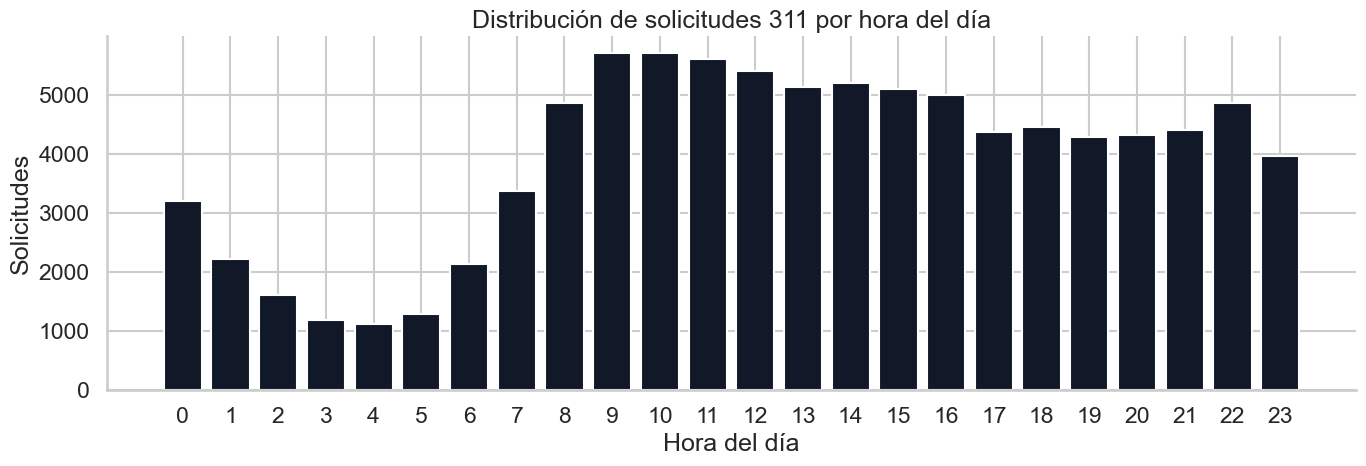

In [14]:
# ── Métrica 3: Distribución por hora del día ──────────────────────────────────
agg_hora = (
    fact.groupby('hour_of_day')
    .agg(n_solicitudes=('Unique Key', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(agg_hora['hour_of_day'], agg_hora['n_solicitudes'], color='#111827')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Solicitudes')
ax.set_title('Distribución de solicitudes 311 por hora del día')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'solicitudes_por_hora.png', dpi=150, bbox_inches='tight')
plt.show()

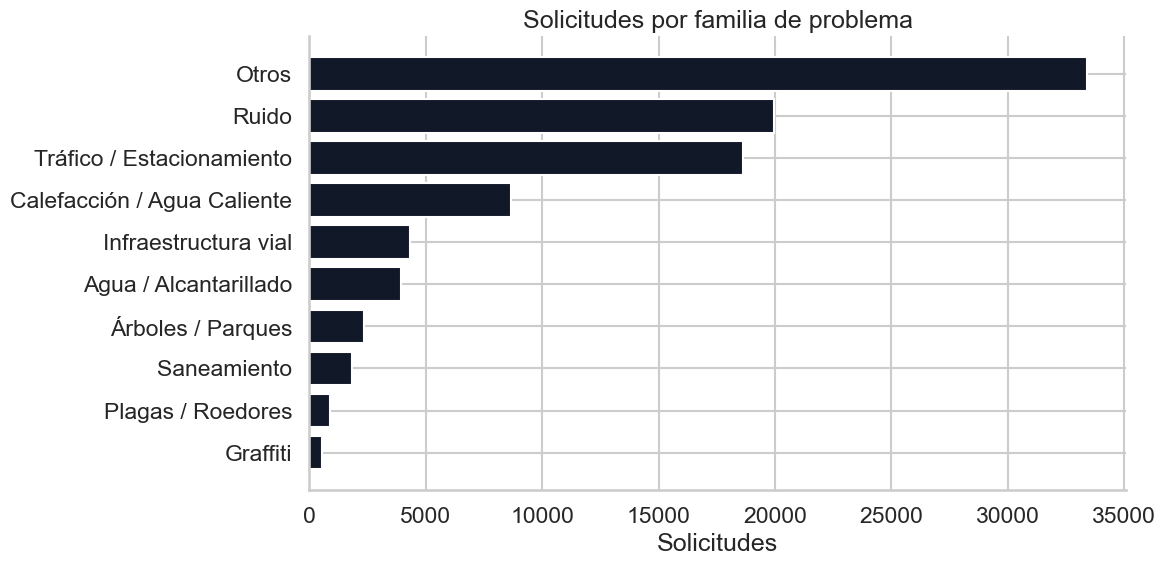

In [15]:
# ── Métrica 4: Top problemas por familia ──────────────────────────────────────
agg_familia = (
    fact.groupby('problem_family')
    .agg(n_solicitudes=('Unique Key', 'count'))
    .reset_index()
    .sort_values('n_solicitudes', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(agg_familia['problem_family'], agg_familia['n_solicitudes'], color='#111827')
ax.set_xlabel('Solicitudes')
ax.set_title('Solicitudes por familia de problema')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'solicitudes_por_familia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Validación de integridad del modelo

Antes de exportar, verificamos dos cosas:
1. Que el modelo no haya inflado ni perdido registros (integridad relacional)
2. Que el modelo estrella sea más eficiente en memoria que la tabla plana (evidencia de la decisión)


In [18]:
# ── 6.1 Checks de integridad relacional ───────────────────────────────────────
validation = pd.DataFrame([
    {'check': 'filas_clean_input',       'value': len(df)},
    {'check': 'filas_fact',              'value': len(fact)},
    {'check': 'unique_keys_input',       'value': df['Unique Key'].nunique()},
    {'check': 'unique_keys_fact',        'value': fact['Unique Key'].nunique()},
    {'check': 'filas_dim_fecha',         'value': len(dim_fecha)},
    {'check': 'filas_dim_geo',           'value': len(dim_geo)},
    {'check': 'filas_dim_agencia',       'value': len(dim_agencia)},
    {'check': 'filas_dim_problema',      'value': len(dim_problema)},
    {'check': 'fact_con_borough_valido', 'value': fact['Borough'].notna().sum()},
    {'check': 'fact_con_resolucion',     'value': fact['resolution_hours'].notna().sum()},
])

print(validation.to_string(index=False))

# Checks críticos
assert len(fact) == len(df),                      'ERROR: fact tiene distinto número de filas que el input'
assert fact['Unique Key'].nunique() == len(fact),  'ERROR: hay Unique Keys duplicados en fact'

print('\n✓ Todos los checks de integridad pasados')

                  check  value
      filas_clean_input  94500
             filas_fact  94500
      unique_keys_input  94500
       unique_keys_fact  94500
        filas_dim_fecha    962
          filas_dim_geo      5
      filas_dim_agencia     16
     filas_dim_problema    187
fact_con_borough_valido  94394
    fact_con_resolucion  91662

✓ Todos los checks de integridad pasados


In [19]:
# ── 6.2 Evidencia cuantitativa: tamaño del modelo estrella vs tabla plana ─────
# Esta comparación respalda con datos la decisión de modelado de la Sección 2.

size_flat_mb = df.memory_usage(deep=True).sum() / 1e6
size_fact_mb = fact.memory_usage(deep=True).sum() / 1e6
size_dims_mb = sum(
    d.memory_usage(deep=True).sum()
    for d in [dim_fecha, dim_geo, dim_agencia, dim_problema]
) / 1e6
size_star_mb  = size_fact_mb + size_dims_mb
reduccion_pct = (1 - size_star_mb / size_flat_mb) * 100

print('=' * 55)
print('  Evidencia de tamaño: flat vs modelo estrella')
print('=' * 55)
print(f'  Tabla plana original:          {size_flat_mb:>8.1f} MB')
print()
print(f'  fact_311:                      {size_fact_mb:>8.1f} MB')
print(f'  Todas las dimensiones:         {size_dims_mb:>8.1f} MB')
print(f'  Modelo estrella (total):       {size_star_mb:>8.1f} MB')
print()
print(f'  Reducción de tamaño:           {reduccion_pct:>7.1f}%')
print('=' * 55)
print()
print('  Interpretación: la reducción se explica porque los atributos')
print('  de baja cardinalidad (Borough, Agency, Problem) se almacenan')
print('  una sola vez en dimensiones en lugar de repetirse en cada')
print(f'  una de las {len(df):,} filas de la tabla plana.')

  Evidencia de tamaño: flat vs modelo estrella
  Tabla plana original:              72.2 MB

  fact_311:                          58.3 MB
  Todas las dimensiones:              0.2 MB
  Modelo estrella (total):           58.5 MB

  Reducción de tamaño:              18.9%

  Interpretación: la reducción se explica porque los atributos
  de baja cardinalidad (Borough, Agency, Problem) se almacenan
  una sola vez en dimensiones en lugar de repetirse en cada
  una de las 94,500 filas de la tabla plana.


---
## 7. Exportación para Tableau

Exportamos cada tabla del modelo como CSV independiente. En Tableau se conectan mediante **Relaciones** (no joins) usando las claves naturales, lo que evita inflación de filas.

**Convención de nombres**: `fact_311.csv`, `dim_fecha.csv`, `dim_geo.csv`, `dim_agencia.csv`, `dim_problema.csv` + agregaciones pre-calculadas.


In [20]:
exports = {
    'fact_311':               fact,
    'dim_fecha':              dim_fecha,
    'dim_geo':                dim_geo,
    'dim_agencia':            dim_agencia,
    'dim_problema':           dim_problema,
    'agg_resolucion_agencia': agg_resolucion_agencia,
    'agg_hora':               agg_hora,
    'agg_familia_problema':   agg_familia,
    'agg_borough_year':       agg_borough_year,
    'validation_checks':      validation,
}

for name, table in exports.items():
    path = OUTPUT_DIR / f'{name}.csv'
    table.to_csv(path, index=False)
    print(f'✓ {name}.csv  →  {table.shape}  →  {path}')

✓ fact_311.csv  →  (94500, 17)  →  c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\notebooks\outputs\week-04-311\fact_311.csv
✓ dim_fecha.csv  →  (962, 7)  →  c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\notebooks\outputs\week-04-311\dim_fecha.csv
✓ dim_geo.csv  →  (5, 2)  →  c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\notebooks\outputs\week-04-311\dim_geo.csv
✓ dim_agencia.csv  →  (16, 2)  →  c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\notebooks\outputs\week-04-311\dim_agencia.csv
✓ dim_problema.csv  →  (187, 3)  →  c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\notebooks\outputs\week-04-311\dim_problema.csv
✓ agg_resolucion_agencia.csv  →  (16, 5)  →  c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\notebooks\outputs\week-04-311\agg_resolucion_agencia.csv
✓ agg_hora.csv  →  (24, 2)  →  c:\Users\nikol\OneDrive\Repositorios\nyc-311-analytics\notebooks\outputs\week-04-311\agg_hora.csv
✓ agg_familia_problema.csv  →  (10, 2)  →  c:\User

---
## 8. Reflexión metodológica

### Estructura del modelo

```
fact_311 (una fila por solicitud)
  │
  ├── dim_fecha     (date)     → Year / Quarter / Month / Day of Week / is_weekend
  ├── dim_geo       (Borough)  → 5 boroughs válidos de NYC
  ├── dim_agencia   (Agency)   → agencias municipales
  └── dim_problema  (Problem)  → 272 tipos + agrupación en 11 familias
```

### Decisiones que pueden defenderse

| Decisión | Alternativa descartada | Razón |
|---|---|---|
| Modelo estrella vs tabla plana | Tabla plana única | La Sección 6.2 muestra reducción medida de tamaño en memoria; además, el modelo estrella garantiza reproducibilidad del análisis vía Git |
| Agrupación de Problem en familias temáticas | Top-N por frecuencia | Top-N agrupa por popularidad, no por semántica — Ruido nocturno y Ruido de construcción quedarían separados aunque sean la misma familia de problema |
| Mediana para tiempo de resolución | Media aritmética | La Métrica 2 muestra que la media es múltiplos mayor que la mediana — distribución con outliers extremos |
| Agregaciones pre-calculadas en Python | Campos calculados en Tableau | Auditables, versionables en Git, consistentes entre todas las vistas del workbook |
| `problem_family` en fact (no solo en dim) | Solo en dimensión | Permite filtrar por familia en Tableau sin configurar la relación — simplifica el workbook |

### Cómo conectar en Tableau

1. Abrir Tableau → Conectar a archivo de texto → seleccionar `fact_311.csv`
2. Arrastrar `dim_fecha.csv` al canvas → definir relación por campo `date`
3. Arrastrar `dim_geo.csv` → relación por `Borough`
4. Arrastrar `dim_agencia.csv` → relación por `Agency`
5. Arrastrar `dim_problema.csv` → relación por `Problem`

Las agregaciones (`agg_*.csv`) se conectan como fuentes independientes para vistas específicas.
